Cargando modelo YOLO con tracking...
Video: 1280x720 @ 30fps
Total frames: 9184

Procesando video con tracking...

(Esto puede tardar un poco más porque rastrea cada vehículo)



requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.7 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 35.5 MB/s eta 0:00:00

requirements: AutoUpdate success ✅ 1.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.7 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 35.5 MB/s eta 0:00:00

requirements: AutoUpdate success ✅ 1.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Progreso: 3.3% - Frame 300/9184
  Vehículos únicos detectados hasta ahora: 32
Progreso: 3.3% - Frame 300/9184
  Vehículos únicos detectados hasta ahora: 32
Progreso: 6.5% - Frame 600/9184
  Vehículos únicos detectados hasta ahora: 49
Progreso: 6.5% - Frame 600/9184
  Vehículos únicos detectados hasta ahora: 49
Progreso: 9.8% - Frame 900/9184
  Vehículos únicos d

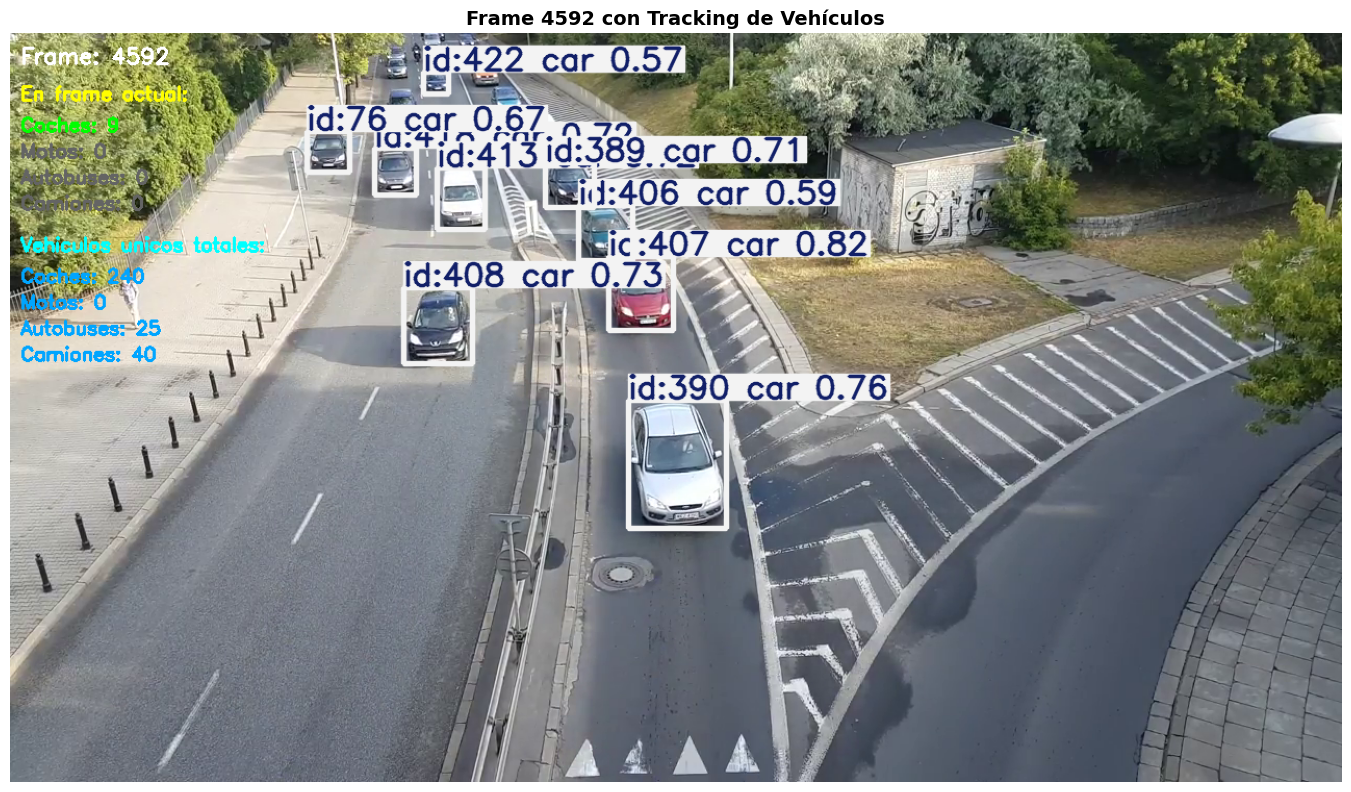


✅ Proceso completado con éxito

NOTA: Se detectaron 635 vehículos ÚNICOS
      (cada vehículo se cuenta solo UNA vez, aunque aparezca en múltiples frames)


In [13]:
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt
from collections import defaultdict

# Cargar modelo CON TRACKING
print("Cargando modelo YOLO con tracking...")
model = YOLO("yolo11n.pt")

# Abrir video
cap = cv2.VideoCapture("video_trafico.mp4")
ancho = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
alto = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"Video: {ancho}x{alto} @ {fps}fps")
print(f"Total frames: {total_frames}\n")

# Video de salida
writer = cv2.VideoWriter('trafficCam.mp4', 
                         cv2.VideoWriter_fourcc(*'mp4v'), 
                         fps, (ancho, alto))

# CONTADORES ÚNICOS - Guardar IDs ya contados
vehiculos_unicos = {2: set(), 3: set(), 5: set(), 7: set()}
nombres = {2: 'Coches', 3: 'Motos', 5: 'Autobuses', 7: 'Camiones'}

# Frame de ejemplo
frame_ejemplo = None
frame_num = 0

print("Procesando video con tracking...\n")
print("(Esto puede tardar un poco más porque rastrea cada vehículo)\n")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    
    frame_num += 1
    
    # TRACKING en vez de solo detección
    # persist=True mantiene los IDs entre frames
    results = model.track(frame, conf=0.5, classes=[2, 3, 5, 7], 
                         persist=True, verbose=False)
    
    # Contar vehículos ÚNICOS en este frame
    detecciones_frame = {2: 0, 3: 0, 5: 0, 7: 0}
    
    # Verificar si hay detecciones con IDs
    if results[0].boxes.id is not None:
        for box in results[0].boxes:
            clase = int(box.cls[0])
            track_id = int(box.id[0])  # ID único del vehículo
            
            # Solo contar si es la primera vez que vemos este ID
            if track_id not in vehiculos_unicos[clase]:
                vehiculos_unicos[clase].add(track_id)
            
            detecciones_frame[clase] += 1
    
    # Dibujar detecciones
    frame_anotado = results[0].plot()
    
    # AÑADIR TEXTO CON CONTEO EN EL FRAME
    y_pos = 30
    cv2.putText(frame_anotado, f"Frame: {frame_num}", 
                (10, y_pos), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    
    y_pos += 35
    cv2.putText(frame_anotado, "En frame actual:", 
                (10, y_pos), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)
    
    y_pos += 30
    for clase in [2, 3, 5, 7]:
        texto = f"{nombres[clase]}: {detecciones_frame[clase]}"
        color = (0, 255, 0) if detecciones_frame[clase] > 0 else (100, 100, 100)
        cv2.putText(frame_anotado, texto, (10, y_pos), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
        y_pos += 25
    
    # Mostrar vehículos ÚNICOS totales
    y_pos += 15
    cv2.putText(frame_anotado, "Vehiculos unicos totales:", 
                (10, y_pos), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)
    
    y_pos += 30
    for clase in [2, 3, 5, 7]:
        count_unico = len(vehiculos_unicos[clase])
        texto = f"{nombres[clase]}: {count_unico}"
        cv2.putText(frame_anotado, texto, (10, y_pos), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 165, 0), 2)
        y_pos += 25
    
    # Guardar video
    writer.write(frame_anotado)
    
    # Guardar frame de ejemplo (mitad del video)
    if frame_num == total_frames // 2:
        frame_ejemplo = frame_anotado.copy()
    
    # Mostrar progreso
    if frame_num % 300 == 0:
        porcentaje = (frame_num / total_frames) * 100
        print(f"Progreso: {porcentaje:.1f}% - Frame {frame_num}/{total_frames}")
        # Mostrar conteo actual
        total_actual = sum(len(v) for v in vehiculos_unicos.values())
        print(f"  Vehículos únicos detectados hasta ahora: {total_actual}")

# Cerrar todo
cap.release()
writer.release()

# ===== RESULTADOS =====
print("\n" + "="*60)
print("RESULTADOS FINALES - VEHÍCULOS ÚNICOS")
print("="*60)
print(f"\nFrames procesados: {frame_num}\n")

print("VEHÍCULOS ÚNICOS DETECTADOS:")
print("-"*60)

total_unicos = 0
for clase in [2, 3, 5, 7]:
    count = len(vehiculos_unicos[clase])
    total_unicos += count
    print(f"  {nombres[clase]:12} : {count:5} vehículos únicos")

print("-"*60)
print(f"  {'TOTAL':12} : {total_unicos:5} vehículos únicos")
print("="*60)

print(f"\n✅ Video guardado: trafficCam.mp4")

# Mostrar frame de ejemplo
if frame_ejemplo is not None:
    print("\n📸 Mostrando frame de ejemplo...\n")
    
    frame_rgb = cv2.cvtColor(frame_ejemplo, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(14, 8))
    plt.imshow(frame_rgb)
    plt.title(f'Frame {total_frames // 2} con Tracking de Vehículos', 
              fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    
    plt.savefig('frame_ejemplo.png', dpi=150, bbox_inches='tight')
    print("✅ Imagen guardada: frame_ejemplo.png")
    plt.show()

print("\n✅ Proceso completado con éxito")
print(f"\nNOTA: Se detectaron {total_unicos} vehículos ÚNICOS")
print(f"      (cada vehículo se cuenta solo UNA vez, aunque aparezca en múltiples frames)")